# Random Forest Classifier for Shopping Preference Prediction

In this notebook we explore Random Forest, one of the most powerful and widely used ensemble machine learning algorithms.

Random Forest improves upon Decision Trees by combining the predictions of multiple trees, reducing variance and improving generalization.

Our objective is to predict a customer’s shopping preference:
- Online
- Store
- Hybrid

using behavioral, demographic, and purchasing features.

This notebook covers:
1. Mathematical intuition of Random Forest
2. Bias–variance trade-off
3. When to use Random Forest
4. When not to use Random Forest
5. Hyperparameter tuning
6. Implementation using Scikit-Learn
7. Model interpretation and feature importance

The notebook integrates the project’s modular ML pipeline:
- src/data_loader.py
- src.preprocess.py

In [48]:
# Setup
import sys
sys.path.append("..")

# Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

# project modules
from src.data_loader import load_raw_data
from src.preprocess import preprocess_dataset

sns.set(style="whitegrid")

## Load the Dataset

We load the dataset using the centralized project data loader.

In [49]:
dataset_name = "online vs store shopping dataset.csv"

df = load_raw_data(dataset_name)

df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


## Data Preprocessing

The preprocessing pipeline performs:

- Feature engineering
- Categorical encoding
- Feature scaling
- Train/test split

In [50]:
X_train, X_test, y_train, y_test, preprocessor = preprocess_dataset(
    df,
    target_column="shopping_preference"
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (9431, 34)
Test shape: (2358, 34)


## Encode Target Variable

In [51]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Mathematical Intuition of Random Forest

Random Forest is an **ensemble learning algorithm** that combines many Decision Trees.

Instead of relying on a single tree, Random Forest trains **multiple trees on different subsets of the data** and combines their predictions.

Two main ideas make Random Forest powerful:

### 1. Bagging (Bootstrap Aggregation)

Each tree is trained on a **random bootstrap sample** of the dataset.

This introduces diversity among trees and reduces variance.

### 2. Random Feature Selection

At each split, the tree considers only a **random subset of features**.

This ensures that trees are **decorrelated**, improving ensemble performance.

Final prediction is made by **majority voting** across trees.

# Bias vs Variance Trade-off

Decision Trees have **low bias but high variance**.

Random Forest reduces variance by averaging many trees.

Effectively:

Decision Tree
→ high variance

Random Forest
→ reduced variance
→ improved generalization

The number of trees controls stability:

- More trees → lower variance
- Too many trees → higher computational cost

# When to Use Random Forest

Random Forest works well when:

✔ Dataset contains complex nonlinear relationships  
✔ Feature interactions are important  
✔ Dataset has many features  
✔ Overfitting is a concern with Decision Trees  

Common applications:

- Customer behavior prediction
- Fraud detection
- Medical diagnosis
- Credit risk modeling

# When NOT to Use Random Forest

Random Forest may not be ideal when:

❌ Model interpretability is critical  
❌ Dataset is extremely large and memory is limited  
❌ Real-time prediction latency must be extremely low  

Because Random Forest consists of **many trees**, prediction can be slower than simpler models.

## Train Baseline Model

In [60]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train_enc)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [61]:
pred_enc = rf.predict(X_test)

pred = le.inverse_transform(pred_enc)

## Model Evaluation

In [65]:
print("Accuracy:", accuracy_score(y_test, pred))

print("F1 Score:", f1_score(y_test, pred, average="weighted"))

print("\nClassification Report:\n")

print(classification_report(y_test, pred, zero_division=0))

Accuracy: 0.9491094147582697
F1 Score: 0.9332041730850726

Classification Report:

              precision    recall  f1-score   support

      Hybrid       0.00      0.00      0.00        74
      Online       0.90      0.81      0.85       235
       Store       0.95      1.00      0.98      2049

    accuracy                           0.95      2358
   macro avg       0.62      0.60      0.61      2358
weighted avg       0.92      0.95      0.93      2358



## Confusion Matrix

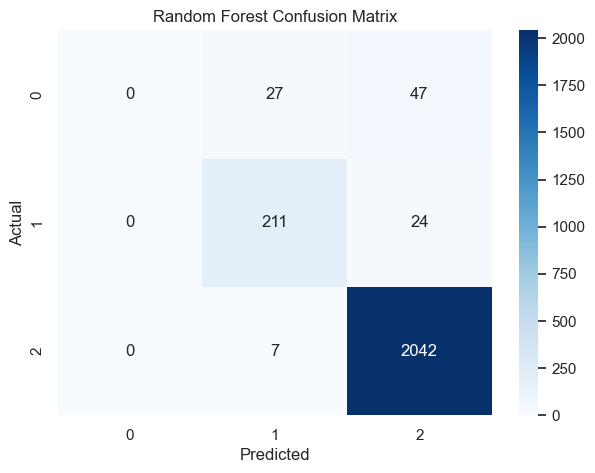

In [55]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.ylabel("Actual")

plt.xlabel("Predicted")

plt.show()

# Hyperparameter Tuning

Important Random Forest parameters:

| Parameter | Meaning |
|------|------|
| n_estimators | Number of trees |
| max_depth | Maximum tree depth |
| min_samples_split | Minimum samples to split |
| min_samples_leaf | Minimum samples in leaf |
| max_features | Number of features per split |

In [56]:
param_grid = {
    "n_estimators": [100,200,300],
    "max_depth": [None,5,10,20],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train_enc)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [66]:
best_rf = grid.best_estimator_

pred_enc = best_rf.predict(X_test)

pred = le.inverse_transform(pred_enc)

print(classification_report(y_test, pred, zero_division=0))

              precision    recall  f1-score   support

      Hybrid       0.00      0.00      0.00        74
      Online       0.86      0.89      0.87       235
       Store       0.97      1.00      0.98      2049

    accuracy                           0.95      2358
   macro avg       0.61      0.63      0.62      2358
weighted avg       0.92      0.95      0.94      2358



# Feature Importance

Random Forest provides **feature importance scores**, indicating which variables influence predictions the most.

In [58]:
importances = best_rf.feature_importances_

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df.head(10)

,feature,importance
10,num__avg_store_spend,0.377168
23,num__online_spend_ratio,0.242130
18,num__need_touch_feel_score,0.030061
25,num__digital_engagement_score,0.029103
22,num__online_order_ratio,0.027730
24,num__avg_spend_per_online_order,0.022278
9,num__avg_online_spend,0.021843
6,num__tech_savvy_score,0.018825
29,num__offline_shopping_preference_score,0.016948
7,num__monthly_online_orders,0.016425


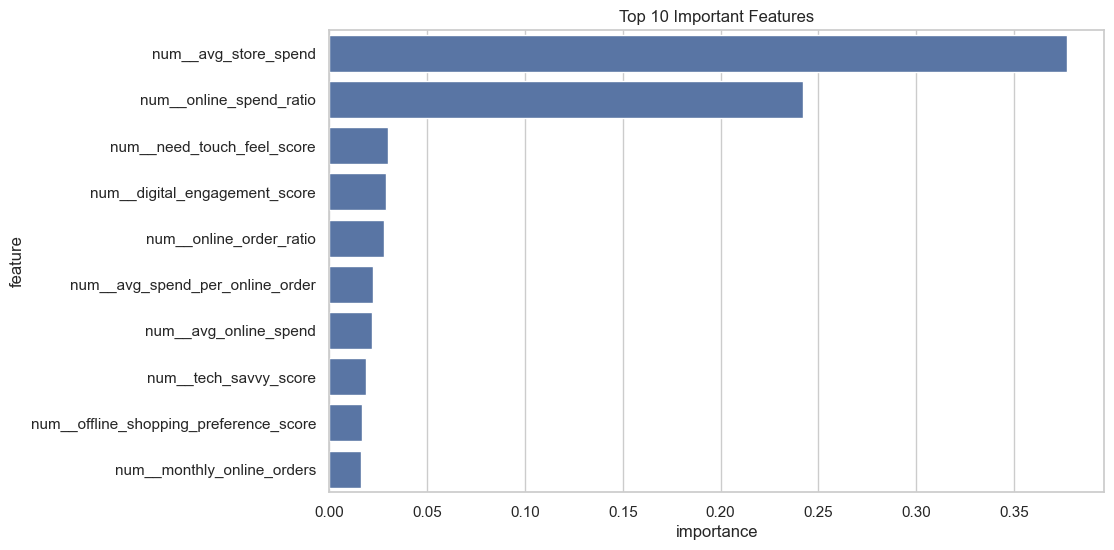

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x="importance",
    y="feature"
)

plt.title("Top 10 Important Features")

plt.show()

# Key Insights

Random Forest captures **complex interactions between customer behavior features**.

Important signals often include:

- online spending ratio
- digital engagement
- discount sensitivity
- purchase frequency

Because Random Forest aggregates many trees, it produces **more stable predictions** than a single Decision Tree.

# Next Models to Explore

Next models in the ML pipeline:

- Gradient Boosting
- Naive Bayes

These algorithms often achieve **state-of-the-art performance** on structured datasets.